In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from sklearn.model_selection import train_test_split

In [2]:
def load_images_from_folder(folder, label, image_size=(64, 64)):
    X = []
    y = []
    for filename in os.listdir(folder):
        file_path = os.path.join(folder, filename)
        try:
            img = Image.open(file_path).convert('RGB')
            img = img.resize(image_size)
            X.append(np.array(img))
            y.append(label)
        except:
            print("waht")
            pass
    return X, y


In [3]:
g_folder = '/content/drive/MyDrive/glass_dataset/train/glasses'
ng_folder = '/content/drive/MyDrive/glass_dataset/train/noglasses'

X_g, y_g = load_images_from_folder(g_folder, label=0)

X_ng, y_ng = load_images_from_folder(ng_folder, label=1)

X = X_g + X_ng
y = y_g + y_ng

#norm
X = np.array(X) / 255.0
y = np.array(y)


In [4]:
print(len(X))
print(len(y))

104
104


In [5]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

# Binary classifier CNN
class SimpleBinaryCNN(nn.Module):
    def __init__(self):
        super(SimpleBinaryCNN, self).__init__()
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=1, kernel_size=3)

        self.pool = nn.MaxPool2d(2, 2)
        self.fc = nn.Linear(31 * 31, 1)  # Adjusted for 64x64 -> (62x62) -> (31x31)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = x.view(x.size(0), -1)   #conv->activ->pool->flatten for fc->
        x = self.fc(x)
        return x





train/test split on the same dataset dist.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, shuffle=True
)


#transformation neede for the vectors
X_train = torch.tensor(X_train, dtype=torch.float32).permute(0, 3, 1, 2)
y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
X_test = torch.tensor(X_test, dtype=torch.float32).permute(0, 3, 1, 2)
y_test = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

In [7]:
X_train.size(2)

64

In [12]:

    model = SimpleBinaryCNN()

    # Use BCEWithLogitsLoss (handles sigmoid internally)
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(model.parameters(), lr=0.001)  #optimizer

    batch_size = len(X)
    inputs = X_train
    labels = y_train

    #forward pass
    outputs = model(inputs)
    loss = criterion(outputs, labels)
    print("Loss before backward:", loss.item())

    # Backward and optimize
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    #train
    for epoch in range(1000):
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

Loss before backward: 0.6932952404022217


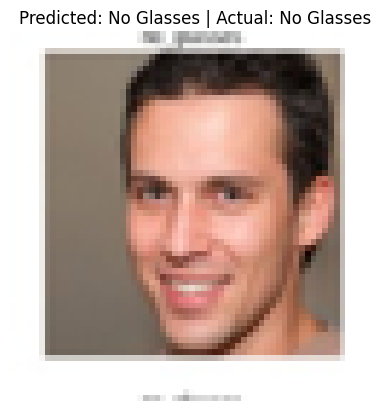

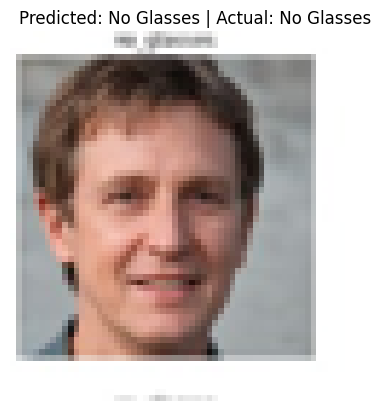

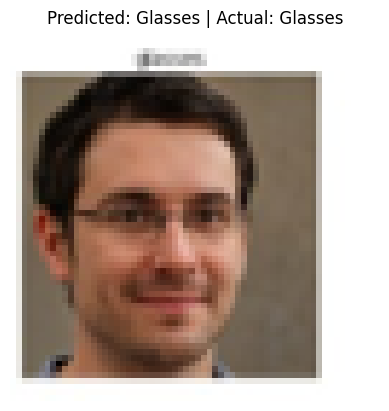

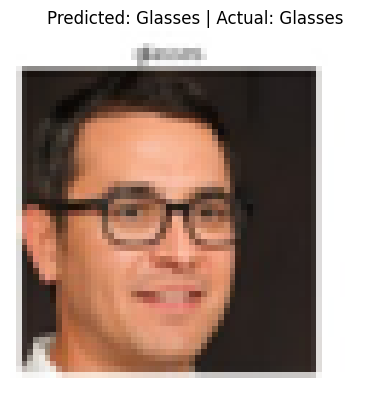

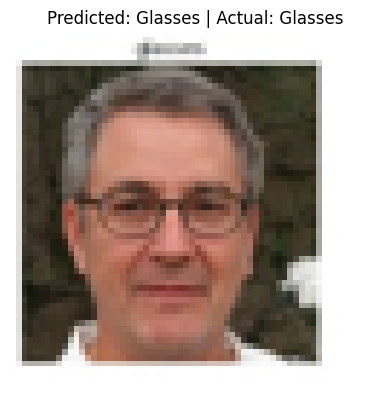

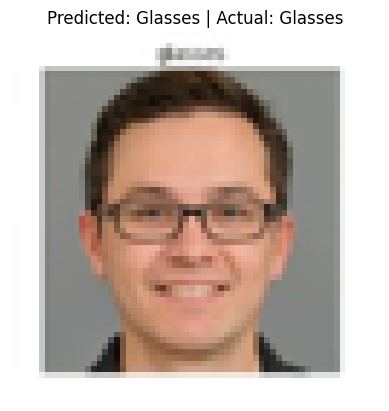

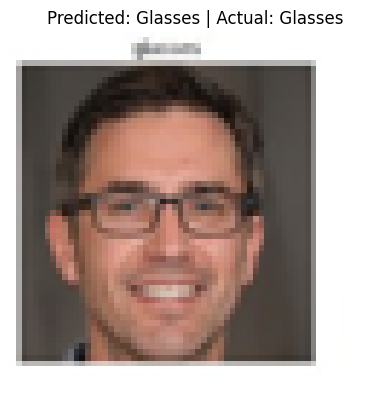

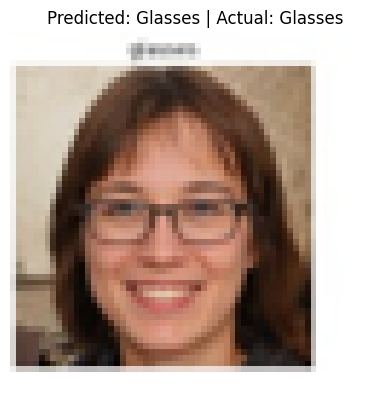

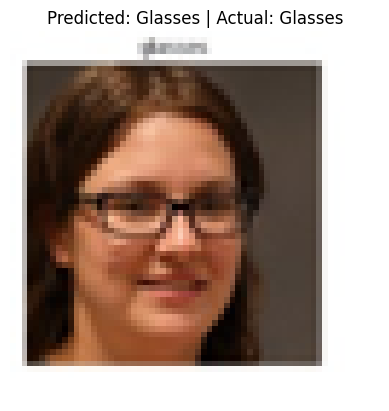

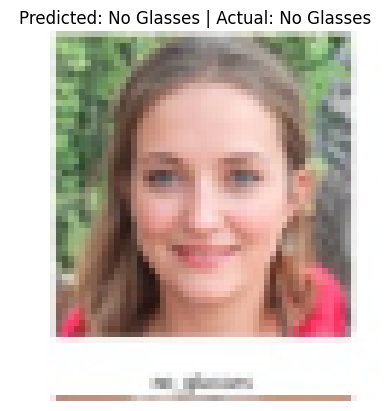

In [13]:
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt


test_dataset = TensorDataset(X_test, y_test)
test_loader = DataLoader(test_dataset, batch_size=1, shuffle=True)



model.eval()

with torch.no_grad():  #no gradient tracking
    for i, (image, label) in enumerate(test_loader):
        output = model(image)
        pred = torch.sigmoid(output).round().item()  # as not done in cnn -=> Sigmoid + round for binary class
        true = int(label.item())

        #img
        img = image.squeeze().permute(1, 2, 0).numpy()  # (H, W, 3)
        plt.imshow(img)
        plt.title(f"Predicted: {'Glasses' if pred == 0 else 'No Glasses'} | Actual: {'Glasses' if true == 0 else 'No Glasses'}")
        plt.axis('off')
        plt.show()

        #a few imgs
        if i >= 9:
            break


In [14]:
model.eval()
correct = 0
total = 0

with torch.no_grad():  #dis for testing
    for images, labels in test_loader:
        outputs = model(images)
        preds = torch.sigmoid(outputs).round()  #0 or 1 for binary
        correct += (preds == labels).sum().item()
        total += labels.size(0)

accuracy = correct / total
print(f"Test Accuracy: {accuracy * 100:.2f}%")

Test Accuracy: 95.24%


test with pic from web, resized to match trained data

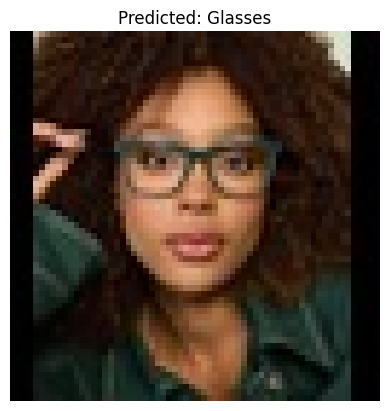

In [15]:
import torch
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np

img = Image.open("/content/glas_test_2 (1).jpeg").convert('RGB')
img = img.resize((64, 64))
px = np.array(img) / 255.0  #norm

#torch tensor and reshape [1, 3, 64, 64]
px_tensor = torch.tensor(px, dtype=torch.float32).permute(2, 0, 1).unsqueeze(0)  #[1, 3, 64, 64]

#eval
model.eval()
with torch.no_grad():
    out = model(px_tensor)
    pred = torch.sigmoid(out).round().item()  #pred


plt.imshow(px)
plt.title(f"Predicted: {'No Glasses' if pred == 1 else 'Glasses'}")
plt.axis('off')
plt.show()


QUANT MODEL IN PYTORCH (one way)

In [16]:
# Dynamic Quantization example (PyTorch)
from torch.quantization import quantize_dynamic

quantized_model = quantize_dynamic(model, {torch.nn.Linear}, dtype=torch.qint8)

quantized_model.eval()
correct = 0
total = 0

with torch.no_grad():
    for images, labels in test_loader:
        outputs = quantized_model(images)
        preds = torch.sigmoid(outputs).round()
        correct += (preds == labels).sum().item()
        total += labels.size(0)

accuracy = correct / total
print(f"Test Accuracy: {accuracy * 100:.2f}%")

Test Accuracy: 95.24%


In [ ]:
!pip install onnxruntime


In [ ]:
# import onnxruntime as ort
# import numpy as np
# from onnxruntime.quantization import quantize_dynamic, QuantType

# model_fp32 = 'model.onnx'
# model_quant = 'model_quantized.onnx'

# # Quantize weights only (this avoids ConvInteger)
# quantize_dynamic(
#     model_input=model_fp32,
#     model_output=model_quant,
#     weight_type=QuantType.QInt8  # or QuantType.QUInt8
#     )



In [ ]:
# !pip uninstall -y onnxruntime
# !pip install onnxruntime-gpu


In [ ]:
# import onnxruntime as ort
# import numpy as np

# # Set up ONNX Runtime session with GPU
# session = ort.InferenceSession("model_quantized.onnx", providers=["CUDAExecutionProvider"])

# # Get input name
# input_name = session.get_inputs()[0].name

# # Dummy input (you can replace with real test image later)
# dummy_input = np.random.rand(1, 3, 64, 64).astype(np.float32)

# # Inference
# output = session.run(None, {input_name: dummy_input})
# logits = output[0]
# probs = 1 / (1 + np.exp(-logits))  # Apply sigmoid since model uses BCEWithLogitsLoss

# # Print prediction
# print("Predicted class:", int(probs[0][0] > 0.5))


In [ ]:
# import onnxruntime as ort
# import numpy as np

# # Load ONNX model
# session = ort.InferenceSession("model_quantized.onnx")

# # Get input name
# input_name = session.get_inputs()[0].name

# # Create dummy input with correct shape (1, 3, 64, 64)
# dummy_input = np.random.rand(1, 3, 64, 64).astype(np.float32)

# # Run inference
# outputs = session.run(None, {input_name: dummy_input})

# # Process output (sigmoid because model uses BCEWithLogitsLoss)
# logits = outputs[0]
# probs = 1 / (1 + np.exp(-logits))
# predicted = (probs > 0.5).astype(int)

# print("Predicted class:", predicted[0][0])


In [ ]:
# pip install onnx

In [ ]:
# torch.onnx.export(model, inputs, "model.onnx", opset_version=13)


NON-QUANTIZED ONNX MODEL

In [ ]:
# import onnxruntime as ort
# sess = ort.InferenceSession("model.onnx", providers=["CPUExecutionProvider"])


In [ ]:
# import onnxruntime as ort
# import numpy as np
# from PIL import Image
# import matplotlib.pyplot as plt

# # Load ONNX model
# ort_session = ort.InferenceSession("binary_classifier.onnx", providers=["CPUExecutionProvider"])

# def preprocess_image(image_path, image_size=(64, 64)):
#     img = Image.open(image_path).convert('RGB')
#     img = img.resize(image_size)
#     img_np = np.array(img).astype(np.float32) / 255.0  # Normalize [0,1]
#     img_np = np.transpose(img_np, (2, 0, 1))  # HWC to CHW
#     img_np = np.expand_dims(img_np, axis=0)   # Add batch dim
#     return img_np, img

# def run_inference(image_path):
#     input_tensor, original_img = preprocess_image(image_path)
#     input_name = ort_session.get_inputs()[0].name
#     outputs = ort_session.run(None, {input_name: input_tensor})
#     logits = outputs[0]
#     probs = 1 / (1 + np.exp(-logits))  # Sigmoid
#     pred_label = "no glasses" if probs[0][0] >= 0.5 else "glasses"
#     print(probs)
#     plt.imshow(original_img)
#     plt.title(f"Prediction: {pred_label} ({probs[0][0]:.2f})")
#     plt.axis('off')
#     plt.show()

# # Replace with your image path
# image_path = "/content/glas_test_2 (1).jpeg"
# run_inference(image_path)


quantized
\


static quant

test -2

In [21]:
pip install onnxruntime

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.4/16.4 MB 57.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.0/46.0 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 86.8/86.8 kB 7.5 MB/s eta 0:00:00


In [22]:

import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import onnx
import onnxruntime as ort
from onnxruntime.quantization import (
    quantize_static, QuantType, QuantFormat, CalibrationDataReader
)

In [41]:
X_test.shape

torch.Size([21, 3, 64, 64])

In [59]:
pip install --upgrade onnxruntime


In [63]:
import torch
import numpy as np
from onnxruntime.quantization import quantize_static, CalibrationDataReader, QuantType, QuantFormat
import onnxruntime as ort


model.eval()
dummy_input = torch.randn(1, 3, 64, 64)
torch.onnx.export(
    model,
    dummy_input,
    "simple_cnn_fp32.onnx",
    input_names=["input"],
    output_names=["output"],
    opset_version=11,
    do_constant_folding=True,
    dynamic_axes={"input": {0: "batch_size"}, "output": {0: "batch_size"}}
)

#calib required => accepts numpy arrays to calib hence need np inputs
class RealCalibrationDataReader(CalibrationDataReader):
    def __init__(self, calibration_data):
        self.data = []
        for i in range(calibration_data.shape[0]):
            sample = calibration_data[i:i+1].astype(np.float32)  #keep batch dim (1,3,64,64)
            self.data.append({"input": sample})
        self.enum_data = iter(self.data)

    def get_next(self):
        return next(self.enum_data, None)

# Convert X_test to numpy if it is a tensor
X_test_np = X_test.numpy() if hasattr(X_test, "numpy") else X_test

#20 samples
calibration_reader = RealCalibrationDataReader(X_test_np[:20])

#static quantization
quantize_static(
    model_input="simple_cnn_fp32.onnx",
    model_output="simple_cnn_int8_qdq.onnx",
    calibration_data_reader=calibration_reader,
    weight_type=QuantType.QInt8,
    activation_type=QuantType.QInt8,
    quant_format=QuantFormat.QDQ,
    per_channel=False,
)


sess = ort.InferenceSession("simple_cnn_int8_qdq.onnx")
input_name = sess.get_inputs()[0].name


outputs = sess.run(None, {input_name: X_test_np[:5].astype(np.float32)})

print("Quantized model output shape:", outputs[0].shape)


Quantized model output shape: (5, 1)


QUANTIZED MODEL ACCURACY

In [54]:
X_test_np = X_test.numpy().astype(np.float32)
y_test_np = y_test.numpy()


In [64]:
correct = 0
total = len(y_test_np)

for i in range(total):
    input_tensor = X_test_np[i:i+1].astype(np.float32)  # Keep batch dimension
    label = y_test[i]

    # Run ONNX model
    output = sess.run(None, {input_name: input_tensor})[0]

    # Apply sigmoid to convert logits to probability/
    prob = 1 / (1 + np.exp(-output[0][0]))
    predicted = int(prob > 0.5)

    if predicted == label:
        correct += 1

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")

Test Accuracy: 95.24%
